New Point: [4 4]
Predicted Class: 1


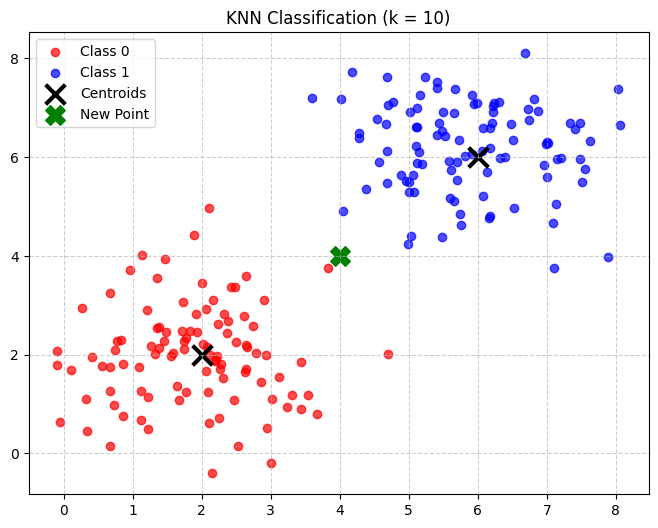

In [1]:

import numpy as np
import matplotlib.pyplot as plt



def generate_binary_blobs(n_samples, center1, center2, std_dev=1.0):
    n_class1 = n_samples // 2
    n_class2 = n_samples - n_class1

    # Class 0
    noise1 = np.random.randn(n_class1, 2)
    X1 = np.array(center1) + noise1 * std_dev
    y1 = np.zeros(n_class1)

    # Class 1
    noise2 = np.random.randn(n_class2, 2)
    X2 = np.array(center2) + noise2 * std_dev
    y2 = np.ones(n_class2)

    # Combine
    X = np.vstack((X1, X2))
    y = np.hstack((y1, y2))

    return X, y


center_A = (2, 2)
center_B = (6, 6)
std_dev = 1.0

X, y = generate_binary_blobs(200, center_A, center_B, std_dev)



k = 10  # number of nearest neighbors

def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))


def knn_predict(X, y, new_point, k):
    distances = []

    for i in range(len(X)):
        dist = euclidean_distance(X[i], new_point)
        distances.append((dist, y[i]))

    # Sort by distance
    distances.sort(key=lambda x: x[0])

    # Take k nearest neighbors
    k_nearest = distances[:k]

    # Majority voting
    labels = [label for _, label in k_nearest]
    prediction = max(set(labels), key=labels.count)

    return prediction

new_point = np.array([4, 4])
prediction = knn_predict(X, y, new_point, k)

print("New Point:", new_point)
print("Predicted Class:", int(prediction))

plt.figure(figsize=(8, 6))

# Class 0
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1],
            color='red', label='Class 0', alpha=0.7)

# Class 1
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1],
            color='blue', label='Class 1', alpha=0.7)

# Centers
plt.scatter([center_A[0], center_B[0]],
            [center_A[1], center_B[1]],
            c='black', marker='x', s=200, linewidth=3,
            label='Centroids')

# New point
plt.scatter(new_point[0], new_point[1],
            color='green', marker='X', s=200,
            label='New Point')

plt.title(f"KNN Classification (k = {k})")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


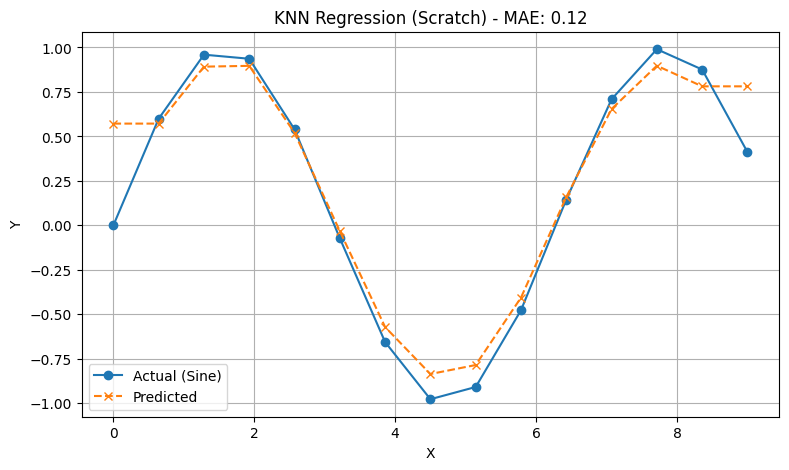

Regression MAE: 0.12088616049312013


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

X = np.linspace(0, 9, 15)            # input values
y_actual = np.sin(X)                 # true function

# Add small noise for realism
y = y_actual + np.random.normal(0, 0.05, len(y_actual))

k = 3

def euclidean_distance(a, b):
    return abs(a - b)

# -----------------------------
# KNN Regression (from scratch)
# -----------------------------
def knn_regression(X, y, x_test, k):
    distances = []
    for i in range(len(X)):
        dist = euclidean_distance(X[i], x_test)
        distances.append((dist, y[i]))

    distances.sort(key=lambda x: x[0])
    k_nearest = distances[:k]

    values = [val for _, val in k_nearest]
    return np.mean(values)

y_pred = np.array([knn_regression(X, y, x, k) for x in X])

mae = np.mean(np.abs(y_actual - y_pred))


plt.figure(figsize=(9, 5))

plt.plot(X, y_actual,
         marker='o', linestyle='-',
         label='Actual (Sine)')

plt.plot(X, y_pred,
         marker='x', linestyle='--',
         label='Predicted')

plt.title(f"KNN Regression (Scratch) - MAE: {mae:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)

plt.show()

print("Regression MAE:", mae)


Accuracy: 1.0


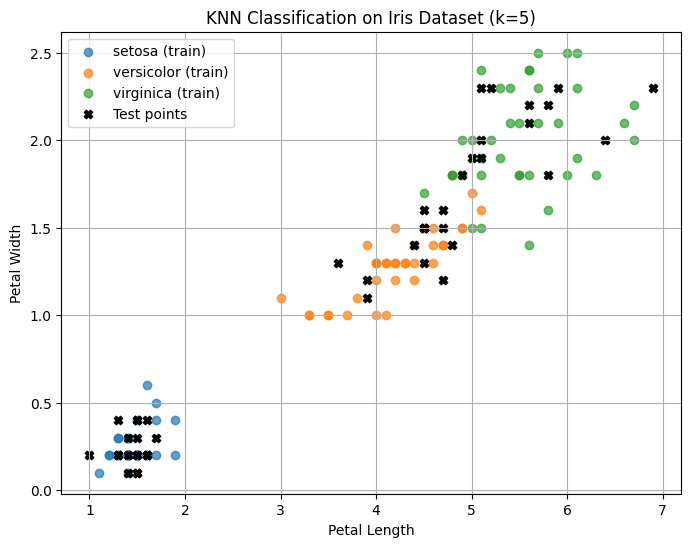

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


iris = load_iris()

# Use only 2 features for plotting
X = iris.data[:, [2, 3]]   # petal length, petal width
y = iris.target


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


k = 5
model = KNeighborsClassifier(n_neighbors=k)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


plt.figure(figsize=(8, 6))

# Plot training points
for i, label in enumerate(iris.target_names):
    plt.scatter(
        X_train[y_train == i, 0],
        X_train[y_train == i, 1],
        label=f"{label} (train)",
        alpha=0.7
    )

# Plot test points
plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    marker='X',
    color='black',
    label='Test points'
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title(f"KNN Classification on Iris Dataset (k={k})")
plt.legend()
plt.grid(True)
plt.show()
